# Grover's Algorithm — Demo

Walks through `algorithms.grover` end to end: build the oracle and circuit
for a specific marked item, visualize it and its measurement histogram, and
run `search()` end to end.

See [../math.md](../math.md) for the amplitude-amplification theory and
[../paper.md](../paper.md) for the circuit derivation this notebook
exercises.

In [1]:
# Make the repo importable regardless of the working directory this
# notebook is executed from (e.g. `jupyter execute` defaults to the
# notebook's own directory, not the repo root).
import sys
from pathlib import Path

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

In [2]:
from algorithms.grover import visualization
from algorithms.grover.circuit import build_grover_circuit
from algorithms.grover.execution import AerExecutor
from algorithms.grover.implementation import _iteration_count, search
from algorithms.grover.oracles import MarkedBitstringOracle

n_qubits, marked = 3, {"101"}
iterations = _iteration_count(n_qubits, len(marked))
print(f"Searching a space of {2**n_qubits} items for {marked}, {iterations} iterations")

Searching a space of 8 items for {'101'}, 2 iterations


## The circuit

Uniform superposition, then `iterations` rounds of (oracle, diffusion),
then measurement.

3 qubits, 10 top-level instructions


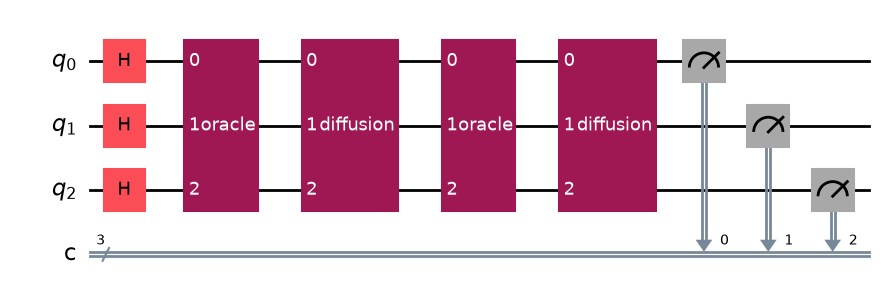

In [3]:
oracle = MarkedBitstringOracle(n_qubits, marked)
circuit = build_grover_circuit(n_qubits, oracle, iterations)
print(f"{circuit.num_qubits} qubits, {len(circuit.data)} top-level instructions")
visualization.circuit_figure(circuit)

## Running it

100 shots on `AerSimulator`. Unlike Shor's algorithm's flat/multi-peaked
histograms (order finding measures a phase, not the answer directly),
Grover's histogram should show one dominant peak at the marked item — that
concentration of amplitude *is* the algorithm working.

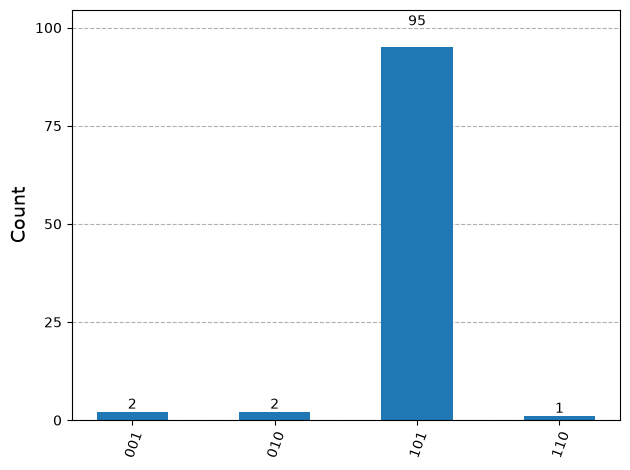

In [4]:
executor = AerExecutor()
counts = executor.run(circuit, shots=100)
visualization.plot_measurement_histogram(counts)

## End to end: `search`

Wraps circuit construction, execution, and a retry loop (for the rare case
the dominant peak isn't the marked item — see math.md) into one call.

In [5]:
result = search(n_qubits, marked)
print(f"search({n_qubits}, {marked}) = {result!r}")
assert result in marked

search(3, {'101'}) = '101'


## Multiple marked items

The oracle and iteration count both generalize to more than one marked
item — `_iteration_count` uses `round(pi/(4*theta) - 1/2)` for
`sin(theta) = sqrt(M/N)`, so more marked items means a larger `theta` and
*fewer* iterations needed.

In [6]:
multi_marked = {"1010", "0101", "1100"}
multi_iterations = _iteration_count(4, len(multi_marked))
print(f"{len(multi_marked)} marked items out of 16 -> {multi_iterations} iterations")
print(search(4, multi_marked))

3 marked items out of 16 -> 1 iterations
0101
